# **TUTORIAL** Prerequisites 2: Processing downloaded archives to prepare data for the workflow


In [1]:
from pyaesa import set_workspace, process_pop_gdp, process_mrio, process_ar6

All of the following processing prepares input data before starting the AESA workflow.
Once the required processed assets exist on disk, continue directly to the notebook that matches the
study endpoint (aSoCC, IO-LCA, aCC, ASR in `tutorials\study_objectives`) rather than manually calling
one by one every downstream function in sequence.

Once processed outputs are on disk they are reused by all subsequent AESA studies as long as what
has been processed (regarding years + MRIO grouping options and LCIA methods) corresponds to the
study's perimeter. Therefore once processing has been done once subsequent uses of pyaesa will
considerably reduce computing time.

# Before starting...

## Prerequisites 0: Set workspace


Every tutorial notebook repeats `set_workspace(...)` as all function calls always assume it has
already run in the current Python session. It defines paths for outputs.


In [ ]:
# Windows example; update this path before running.
set_workspace(r"C:\Users\username\Documents\aesa_workspace")

# macOS example; update this path before running.
# set_workspace("/Users/username/Documents/aesa_workspace")

## Prerequisites 1: Download data

Make sure you ran the notebook `/tutorials/core_prerequisites/1_download_data.ipynb` in the same workspace.


# Prerequisites 2: Process data



Processing converts the raw files downloaded by the download functions into tables and matrices that
AESA workflow functions can reuse deterministically accross case studies.


This notebook covers the full Process family:

- `process_pop_gdp(...)`
- `process_mrio(...)`
- `process_ar6(...)`

Downstream reuse summary:

| Function | Main outputs | Reused later by |
| --- | --- | --- |
| `process_pop_gdp` | harmonized historical and prospective SSP population/GDP tables | `deterministic_asocc(...)` and uncertainty workflows built on allocation outputs |
| `process_mrio` | processed MRIO tables, optional regional and sectoral grouping, optional LCIA characterization | `deterministic_asocc(...)`, `deterministic_io_lca(...)`, `uncertainty_io_lca(...)` |
| `process_ar6` | harmonized dynamic climate change carrying capacity pathways | `deterministic_ar6_cc(...)`, `uncertainty_ar6_cc(...)`, dynamic aCC / ASR workflows |

## Population and GDP PPP data: `process_pop_gdp(...)`

### Description

#### What the function does and what later functions reuse from it


`process_pop_gdp(...)` harmonizes the raw historical and SSP population / GDP inputs into the
processed tables later reused by allocation and projection workflows whenever the selected
allocation methods depend on population, GDP, or GDP per capita drivers.

Some World Bank and SSP entities are grouped under their *"parent country"* so that they are treated
consistently within their corresponding EXIOBASE/OECD *"parent country"*, rather than as part of
Rest of the World (RoW) regions.

This adjustment ensures coherence between World Bank/SSP datasets and EXIOBASE/OECD coverage,
following the list of countries within EXIOBASE RoW regions described by **Bjelle et al. (2020)**.
Without this grouping, several countries would incorrectly appear as belonging to RoW, although they
are already accounted for within their parent country.

The *"parent child"* relationships used for this grouping are defined in the matching files through
the columns **`group_parent`** and **`parent_iso3_code`**.

**Reference**

- Bjelle, E. L., Tobben, J., Stadler, K., Kastner, T., Theurl, M. C., Erb, K. H., Olsen, K. S.,
  Wiebe, K. S., & Wood, R. (2020). Adding country resolution to EXIOBASE: Impacts on land use
  embodied in trade. *Journal of Economic Structures*, 9(1), 1-25.

##### Historical data (World Bank)


For World Bank data, the relevant *"parent country"* matching files are `wb_exiobase_matching.csv`
and `wb_oecd_matching.csv`.

Missing data in the World Bank database are completed via log linear regression using all available
years (logs are produced to report it).

In the World Bank database, Taiwan (TWN) is included within China (CHN) while reported separately in SSP scenarios. Therefore, to ensure consistency across datasets, Taiwan is added via the International Monetary Fund [World Economic Outlook database](https://www.imf.org/external/datamapper/profile/TWN), and removed from China (CHN) in the World Bank database.

*Unit harmonization (GDP PPP base year rebasing)*: World Bank GDP series are retrieved as GDP, PPP
constant 2021 international dollars. To ensure unit consistency with SSP projections expressed in
constant 2017 international $, all World Bank GDP values are rebased from 2021 to 2017 international
dollars by applying a single scalar conversion factor derived from the United States GDP deflator
(World Bank indicator `NY.GDP.DEFL.KD.ZG`) compounded over 2018 to 2021.

##### Prospective data (SSP)

For SSP scenarios, the relevant *"parent country"* matching files are `ssp_exiobase_matching.csv`
and `ssp_oecd_matching.csv`.

As SSP data are provided at five year intervals, intermediate years are estimated through linear
interpolation.

#### Public argument checklist
The table lists all arguments; the same definitions are available in the function docstring.

<div class="pyaesa-argument-legend">
<div class="pyaesa-default-block" style="color:#087f5b"><strong>Green items = default if omitted.</strong></div>
</div>

Do not write green items when the default is intended.

<details open>
<summary><code>process_pop_gdp(...)</code> arguments</summary>

<table>
<thead><tr><th>Argument</th><th>Description</th></tr></thead>
<tbody>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>past_years</code></td><td>If <code>True</code>, build the historical (World Bank + IMF)<br>&#10;processed output. <strong>Default</strong> <code>True</code> includes the historical output.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>future_years</code></td><td>If <code>True</code>, build the SSP processed output.<br>&#10;<strong>Default</strong> <code>True</code> includes the prospective output.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>refresh</code></td><td>If <code>True</code>, clear and recompute only the selected processed population and GDP tables under <code>data_processed/pop_gdp</code>. <code>past_years=True</code> refreshes <code>wb_processed.csv</code>, its metadata, and the World Bank fill log. <code>future_years=True</code> refreshes <code>ssp_processed.csv</code> and its metadata. Raw downloads and project outputs are not refreshed. <strong>Defaults to</strong> <code>False</code>.</td></tr>
</tbody>
</table>

</details>


### Running `process_pop_gdp(...)`

In [ ]:
# Process both historical and future population / GDP inputs.
process_pop_gdp()

## MRIO data: `process_mrio(...)`

### Description

#### What the function does and what later functions reuse



`process_mrio(...)` parses the raw downloaded MRIO archives, computes AESA specific metrics and
responsibility propagation matrices, optionally applies grouping, and optionally performs LCIA
characterization for EXIOBASE sources.

The processed MRIO archives are used by:

- `deterministic_asocc(...)` reuses processed MRIO outputs for allocated shares
- `deterministic_io_lca(...)` and `uncertainty_io_lca(...)` reuse processed MRIO outputs for IO-LCA
  computation and later ASR LCA workflows
- deterministic and uncertainty aCC / ASR workflows depend on those same upstream outputs whenever
  they reuse allocation and/or IO-LCA results.



#### Method


##### MRIO parsing and AESA enacting metric processing


MRIO archives are parsed with the Python library *PyMRIO* (Stadler, 2021).

The baseline processing option computes UNCASExt metrics (see Appendix A in de Bantel et al., 2026)
later used by allocation:

- utility enacting metrics: final demand (`FD`) and gross value added (`GVA`)
- utility propagation matrices: `x_to_rc`, `kappa`, and `omega_reg`
- EXIOBASE LCIA enacting metrics when `lcia_method` is requested: consumption based (CBA) and
  production based (PBA) accounting

Before enacting metric computation, clipped non negativity rules are applied to:

- `FD` (`Y` after summing across final demand categories and producing regions)
- `GVA` (`factor_inputs.F` after summing across value added categories)

Negative totals are clipped to zero, and clipping diagnostics are written under
`data_processed/logs/mrio_logs/`.

**Reference**

- Stadler, K. (2021). Pymrio - A Python Based Multi Regional Input Output Analysis Toolbox. *Journal of Open Research Software*, 9(1). <https://doi.org/10.5334/jors.251>



##### Optional persistence outputs



The following processing options are optional and default to `False` in `process_mrio(...)`. They are not
required by the allocation workflow and should usually remain disabled to reduce on disk output size
and processing time.

- `keep_intermediate_uncasext=True`
  - needed only by `deterministic_io_lca(..., upstream_analysis=True)` to compute diagnostic upstream
    supply chain decomposition of impact sources
  - keeps UNCASExt post clip core matrices at the year root (`A`, `G`, `L`, `Z`)
  - keeps characterized LCIA extension matrices used by UNCASExt LCIA computations (`S`, `M`) under
    `extensions/<method>/`
  - increases one year processed MRIO storage by about +1.9 GB for EXIOBASE 3.10.2 ixi
    (about 9.4x total), +2.9 GB for EXIOBASE 3.10.2 pxp (about 11.3x total), and
    +500 MB for OECD ICIO v2025 (about 3.4x total)
- `pymrio_calc_all=True` (never used by downstream pyaesa public functions)
  - computes and stores the full PyMRIO `calc_all` payload under `preclip/`
  - stores preclip core matrices and LCIA related matrices when LCIA method(s) are requested

When both are enabled, both are written in addition to the baseline UNCASExt enacting metrics and
propagation matrices. Enabling either processing option increases I/O, and enabling `pymrio_calc_all=True` also
increases compute time substantially.



##### Optional MRIO grouping (regions / sectors)



Depending on the study objective, users may need to group regions and/or sectors into macro regions
or macro sectors aligned with the study perimeter.

The same instructions are reproduced in `README_grouping.txt` in the active
`data_raw/mrio/<source>/grouping` folder. If grouped MRIO outputs are later used with LCIA
uncertainty, also follow `README_grouped_and_aggregate_lcia_covs.txt` in
`data_raw/mrio/exiobase_3/lcia/carbon_accounts_covs/`.

Workflow:

1. Copy the appropriate grouping template from the active MRIO grouping folder
   `data_raw/mrio/<source>/grouping` in the workspace.

   - **Sector templates:**
      - *OECD*: `data_raw/mrio/oecd_v2025/grouping/group_sec_template.csv`
      - *EXIOBASE ixi*: `data_raw/mrio/exiobase_3/grouping/ixi/group_sec_template.csv`
      - *EXIOBASE pxp*: `data_raw/mrio/exiobase_3/grouping/pxp/group_sec_template.csv`

      **N.B.**: A detailed description of sectors provided by EXIOBASE is reproduced:
      `data_raw/mrio/exiobase_3/sector_classification.xlsx`

   - **Region templates:**
      - *OECD*: `data_raw/mrio/oecd_v2025/grouping/group_reg_template.csv`
      - *EXIOBASE*: `data_raw/mrio/exiobase_3/grouping/group_reg_template.csv`

2. Save the copied file as `group_reg_<name>.csv` and/or `group_sec_<name>.csv`.

3. Edit the `grouped_mrio` column.
   - No blank values are allowed.
   - Every original region or sector must be assigned to a group. If a region or sector is not
     grouped, repeat its original name in the `grouped_mrio` column.

4. Run `process_mrio(...)` with grouping enabled:

```python
group_reg = True        # for regional aggregation
group_sec = True        # for sector aggregation
group_version = "<name>"
```

If both region and sector grouping are used, both grouping CSVs should share the same `<name>`. When
loading grouped processed MRIOs later, use `group_version="<name>"` consistently.

---

**Provided grouping tables shipped with the package**

**Region grouping**

**`group_reg_eu27`**

Aggregates all EU member states into a single region `EU27`.
All other regions remain unchanged.

It can be called in processing via:

```python
group_reg = True
group_version = "eu27"
```

**`group_reg_world`**

Aggregates all regions into a single region `World`.

It can be called in processing via:

```python
group_reg = True
group_version = "world"
```

**Provided EXIOBASE ixi sector groupings**

**`group_sec_elec`**

Groups EXIOBASE ixi electricity sectors together.

**`group_sec_oecd_d`**

Groups EXIOBASE ixi electricity, gas, and water sectors to match OECD ICIO sector D resolution.


##### Optional LCIA characterization



`lcia_method` accepts one method name or a list of method names, for example
`lcia_method=["pb_lcia", "gwp100_lcia"]`. If no `lcia_method` is provided, no LCIA characterization
is computed.

Additional LCIA methods can be considered by the package. See the tutorial section below.

###### `pb_lcia`


The Planetary Boundary life cycle impact assessment method (PB LCIA) was introduced by Ryberg et al.
(2018). The package characterization matrices combine that method family with updates from Yang &
Paulillo (2025, 2026) and the BI FD implementation from Galan Martin et al. (2021).

**Modified compared to the cited sources**

- For the Biosphere Integrity planetary boundary, the Functional Diversity control variable via the
  Biodiversity Intactness Index is selected (BI FD). BI FD implementation follows Galan Martin et
  al. (2021). This control variable is also available for process based LCA in the ASR route.

**N.B.**

- In this package, the BI FD control variable is divided into BI FD GHG and BI FD LAND to
  distinguish climate and land use related components. This separation is necessary to ensure that
  historical responsibility is calculated consistently for each driver. For climate change,
  cumulative GHG emissions over time must be considered. In contrast, the land use indicator
  measures annual area occupied, not newly converted area, meaning that the same land appears every
  year if it remains in use. Therefore, summing land occupation values over multiple years would
  result in double counting the same area. In the final results, both are then summed back together
  to form a single BI FD control variable.
- For BI FD GHG, the PB LCIA characterization matrix proposed in this package uses an updated GHG
  list and characterization factors aligned with EF 3.1, as proposed by Yang & Paulillo (2025,
  2026). The added greenhouse gas stressors are documented in the packaged characterization matrix.
- For BI FD LAND, cropland stressors are mapped to the former Occupation, annual crop stressor.
  Infrastructure land is represented through artificial surfaces for the Occupation, urban
  stressor.

**References**

- Yang, Q., & Paulillo, A. (2026). Quantifying environmental impacts on planetary boundaries: A refined and validated impact assessment method. *Environmental Impact Assessment Review*, 119, 108355. https://doi.org/10.1016/j.eiar.2026.108355

- Yang, Q., & Paulillo, A. (2025). Advancing Planetary Boundaries Allocation: Systematic Comparison of Sharing Principles for National Level Absolute Environmental Sustainability Assessments. *Procedia CIRP*, 135, 875-880. https://doi.org/10.1016/j.procir.2024.12.087

- Vazquez, D., Galan Martin, A., Tulus, V., & Guillen Gosalbez, G. (2023). Level of decoupling between economic growth and environmental pressure on Earth system processes. *Sustainable Production and Consumption*, 43, 217-229. https://doi.org/10.1016/j.spc.2023.11.001

- Galan Martin, A., Tulus, V., Diaz, I., Pozo, C., Perez Ramirez, J., & Guillen Gosalbez, G. (2021). Sustainability footprints of a renewable carbon transition for the petrochemical sector within planetary boundaries. *One Earth*, 4(4), 565-583. https://doi.org/10.1016/j.oneear.2021.04.001

###### `gwp100_lcia`

This LCIA method characterizes greenhouse gas stressors with factors aligned with EF 3.1, following
Yang & Paulillo (2025, 2026).

**References**

- Yang, Q., & Paulillo, A. (2026). Quantifying environmental impacts on planetary boundaries: A refined and validated impact assessment method. *Environmental Impact Assessment Review*, 119, 108355. https://doi.org/10.1016/j.eiar.2026.108355

- Yang, Q., & Paulillo, A. (2025). Advancing Planetary Boundaries Allocation: Systematic Comparison of Sharing Principles for National Level Absolute Environmental Sustainability Assessments. *Procedia CIRP*, 135, 875-880. https://doi.org/10.1016/j.procir.2024.12.087

###### Adding additional LCIA methods


The instructions for adding custom EXIOBASE LCIA characterization matrices are reproduced in
`data_raw/mrio/exiobase_3/lcia/characterization_factors_matrices/README_add_custom_lcia_characterization_matrices.txt`.

**Proposition of new publicly available LCIA methods**

Users are encouraged to propose additional publicly available LCIA methods via a pull request so
they can be integrated into the package list of supported `lcia_method` and made available to all
users.

**Tutorial: adding new LCIA methods (for personal use and/or to prepare a public release)**

*1. Characterization matrix used directly for EXIOBASE characterization*

- These instructions are reproduced in
  `data_raw/mrio/exiobase_3/lcia/characterization_factors_matrices/README_add_custom_lcia_characterization_matrices.txt`.
- Add the characterization matrix as
  `data_raw/mrio/exiobase_3/lcia/characterization_factors_matrices/<method>.csv`
- Two characterization template families are accepted:
  - standard template: `name_lcia_template.csv`
  - planetary boundary template: `name_lcia_planetary_boundary_template.csv`
- The method name must match the filename stem because the package resolves the characterization
  file as `data_raw/mrio/exiobase_3/lcia/characterization_factors_matrices/<method>.csv`
- This is the file used directly when `lcia_method="<method>"` is requested in `process_mrio(...)`,
  `deterministic_io_lca(...)`, or `deterministic_asocc(...)`
- Direct characterization uses the `impact` rows, not `impact_parent`, for the characterization
  algebra itself
- Even so, if the method may later be used with historical responsibility allocation method,
  structure the characterization matrix from the beginning with the final parent category in
  `impact_parent` and the specific split sub impact in `impact`
  - when no split is needed, write the same label in both columns
  - this keeps the characterization matrix aligned with the later `<method>_rps.csv` mapping and
    with parent level impact unit tracking
- Use the standard template when a generic `impact_full_name` label is sufficient
- Use the planetary boundary template only when the file should preserve explicit `Planetary
  boundary` / `Control variable` vocabulary
  - for concrete patterns, see `name_lcia_template.csv`, `name_lcia_planetary_boundary_template.csv`, and
    the PB LCIA note above regarding BI FD
- All the following EXIOBASE extension families can be characterized: *land, employment, material,
  air emissions, water, factor inputs, nutrients*

*2. Responsibility period table used only by historical responsibility allocation method (PR-HR at
country level)*

- These instructions are reproduced in
  `data_raw/mrio/exiobase_3/lcia/responsibility_periods/README_add_custom_lcia_responsibility_periods.txt`.
- Add the responsibility period table as
  `data_raw/mrio/exiobase_3/lcia/responsibility_periods/<method>_rps.csv`
- Two responsibility period template families are accepted:
  - standard template: `name_lcia_rps_template.csv`
  - planetary boundary template: `name_lcia_rps_planetary_boundary_template.csv`
- This table is needed only for applying the historical responsibility allocation method
- The package resolves it as `data_raw/mrio/exiobase_3/lcia/responsibility_periods/<method>_rps.csv`
- Reuse the same `impact` / `impact_parent` structure as in the characterization matrix
- This is where the specific responsibility period is actually defined for each `impact`, while
  later aggregation back to the parent category follows `impact_parent`
- Use the standard template when a generic `impact_full_name` label is sufficient
- Use the planetary boundary template only when the file should preserve explicit `Planetary
  boundary` / `Control variable` vocabulary and detailed duration or citation notes
  - for concrete patterns, see `name_lcia_template.csv`, `name_lcia_planetary_boundary_template.csv`,
    `name_lcia_rps_template.csv`, `name_lcia_rps_planetary_boundary_template.csv`, and the PB LCIA note
    above regarding BI FD

*3. Static carrying capacity file used by denominator workflows*

- These instructions are reproduced in
  `data_raw/carrying_capacities/README_add_custom_carrying_capacities.txt`.
- If the new LCIA method should also support package static carrying capacity workflows, add
  `pyaesa/workspace_initialisation/prerequisites/carrying_capacities/<method>_cc_steady_state.csv`
- Two template families are accepted:
  - standard template: `name_lcia_cc_steady_state_template.csv`
  - planetary boundary template: `name_lcia_cc_steady_state_planetary_boundary_template.csv`
- Use the standard template when the file should expose the generic label column
  `impact_full_name`
- Use the planetary boundary template only when the file should preserve explicit `Planetary
  boundary` / `Control variable` vocabulary
- This template choice does **not** change the computations. The package normalizes both schemas to
  the same internal contract for validation, figure metadata, aCC, ASR, and external file checks.
  The difference is only the accepted column vocabulary and the resulting display labels
- The standard schema requires `impact_full_name`, `impact`, `impact_unit`, `min_cc`, and `max_cc`
- The planetary boundary schema requires `Planetary boundary`, `Control variable`, `impact`,
  `impact_unit`, `min_cc`, and `max_cc`
- Most new LCIA methods are file driven once the characterization matrix, the optional
  responsibility period table, and the optional static carrying capacity CSV exist
- Code changes are still needed only when the method requires an explicit allocation fallback or a
  dynamic climate binding in `pyaesa/shared/lcia/contracts.py`
- If only a `min_cc` value is proposed and no `max_cc` is provided, threshold uncertainty is not
  available for that static carrying capacity source


#### Available MRIO sources


| Source key | Historical temporal coverage | Notes |
| --- | --- | --- |
| `exiobase_3102_ixi` | 1995-2024 | EE MRIO: EXIOBASE ixi option; **2023** and **2024** are nowcasted |
| `exiobase_3102_pxp` | 1995-2024 | EE MRIO: EXIOBASE pxp option; **2023** and **2024** are nowcasted |
| `oecd_v2025` | 1995-2022 | MRIO: OECD ICIO ixi |

*EXIOBASE 3.9.6 is also available as `exiobase_396_ixi` and `exiobase_396_pxp` for 1995-2022.*

Approximate `process_mrio(...)` first run storage and runtime:

| Source | One year | All years |
| --- | --- | --- |
| `exiobase_3102_ixi` | 230 MB, 1 min | 6.7 GB and 25 min for 1995-2024 |
| `exiobase_3102_pxp` | 280 MB, 1 min | 8.2 GB and 36 min for 1995-2024 |
| `oecd_v2025` | 210 MB, <1 min | 5.8 GB and 5 min for 1995-2022 |

*Measurements use original classification, `keep_intermediate_uncasext=False`, and `pymrio_calc_all=False`. EXIOBASE measurements use `lcia_method="pb_lcia"`. They were taken on Windows 11 with Python 3.14, an 11th Gen Intel Core i7 1165G7 CPU, 32 GB RAM.*


#### Public argument checklist
The table lists all arguments; the same definitions are available in the function docstring.

<div class="pyaesa-argument-legend">
<div class="pyaesa-default-block" style="color:#087f5b"><strong>Green items = default if omitted.</strong></div>
<div class="pyaesa-optional-block" style="color:#c45f00"><strong>Orange items = optional feature skipped if omitted.</strong></div>
</div>

Do not write green or orange items when that behavior is intended.

<details open>
<summary><code>process_mrio(...)</code> arguments</summary>

<table>
<thead><tr><th>Argument</th><th>Description</th></tr></thead>
<tbody>
<tr><td style="vertical-align:top; white-space:nowrap;"><code>source</code></td><td>MRIO source key (<code>&quot;exiobase_396_ixi&quot;</code>,<br>&#10;<code>&quot;exiobase_396_pxp&quot;</code>, <code>&quot;exiobase_3102_ixi&quot;</code>,<br>&#10;<code>&quot;exiobase_3102_pxp&quot;</code>, or <code>&quot;oecd_v2025&quot;</code>).</td></tr>
<tr><td style="vertical-align:top; white-space:nowrap;"><code>years</code></td><td>Studied years. Accepts a single year, list, or range. If<br>&#10;<strong>omitted</strong>, all available MRIO<br>&#10;years for the selected source/group version are used.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>refresh</code></td><td>If <code>True</code>, clear and recompute only the requested processed MRIO year folders inside the resolved source and classification output scope. The output scope is <code>data_processed/mrio/&lt;source&gt;/&lt;version_tag&gt;</code>, where <code>version_tag</code> is <code>original_classification</code> for ungrouped processing or <code>custom_classification_&lt;group_version&gt;</code> for grouped processing. For each requested year, the corresponding processed year folder and metadata year entry are removed before recomputation. Raw downloads and project outputs are not refreshed. <strong>Defaults to</strong> <code>False</code>.</td></tr>
<tr class="pyaesa-optional-row" style="color:#c45f00;"><td style="vertical-align:top; white-space:nowrap;"><code>lcia_method</code></td><td>LCIA method(s) used to characterize MRIO<br>&#10;environmental stressors into the selected method(s) impact<br>&#10;categories (for example <code>&quot;pb_lcia&quot;</code> or<br>&#10;<code>[&quot;pb_lcia&quot;, &quot;gwp100_lcia&quot;]</code>). <code>None</code> skips LCIA<br>&#10;characterization. <strong>Defaults to</strong> <code>None</code>. pyaesa currently supports<br>&#10;LCIA characterization only for EXIOBASE sources. To add a custom<br>&#10;LCIA method, follow<br>&#10;<code>README_add_custom_lcia_characterization_matrices.txt</code> in<br>&#10;<code>data_raw/mrio/exiobase_3/lcia/characterization_factors_matrices/</code><br>&#10;and pass the custom method file stem here.</td></tr>
<tr class="pyaesa-optional-row" style="color:#c45f00;"><td style="vertical-align:top; white-space:nowrap;"><code>group_reg</code></td><td>If <code>True</code>, aggregate regions using a grouping file.<br>&#10;<strong>Default</strong> <code>False</code> keeps native source regions.</td></tr>
<tr class="pyaesa-optional-row" style="color:#c45f00;"><td style="vertical-align:top; white-space:nowrap;"><code>group_sec</code></td><td>If <code>True</code>, aggregate sectors using a grouping file.<br>&#10;<strong>Default</strong> <code>False</code> keeps native source sectors.</td></tr>
<tr class="pyaesa-optional-row" style="color:#c45f00;"><td style="vertical-align:top; white-space:nowrap;"><code>group_version</code></td><td>Grouping version tag used to resolve the region/sector<br>&#10;mapping CSVs. Required when <code>group_reg</code> or <code>group_sec</code> is True.<br>&#10;<strong>Defaults to</strong> an empty string for ungrouped processing. Follow<br>&#10;<code>README_grouping.txt</code> in the active<br>&#10;<code>data_raw/mrio/&lt;source&gt;/grouping</code> folder to name grouping<br>&#10;versions and place the matching mapping CSVs. If grouped outputs are later<br>&#10;used with LCIA uncertainty, also follow<br>&#10;<code>README_grouped_and_aggregate_lcia_covs.txt</code> in<br>&#10;<code>data_raw/mrio/exiobase_3/lcia/carbon_accounts_covs/</code>.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>keep_intermediate_uncasext</code></td><td>If <code>True</code>, keep intermediate UNCASExt<br>&#10;matrices. These outputs are not used by downstream public<br>&#10;functions, except by <code>deterministic_io_lca(...)</code> when upstream<br>&#10;supply chain analysis is requested with <code>upstream_analysis=True</code>.<br>&#10;Written files are the post clip core matrices (<code>A</code>, <code>G</code>, <code>L</code>,<br>&#10;<code>Z</code>, <code>unit</code>), plus characterized LCIA <code>extensions/</code> payloads.<br>&#10;This increases one year processed MRIO storage by about +1.9 GB for<br>&#10;EXIOBASE 3.10.2 ixi (about 9.4x total), +2.9 GB for EXIOBASE<br>&#10;3.10.2 pxp (about 11.3x total), and +500 MB for OECD ICIO v2025<br>&#10;(about 3.4x total). <strong>Default</strong> <code>False</code> writes only the<br>&#10;public processed outputs.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>pymrio_calc_all</code></td><td>If <code>True</code>, write PyMRIO function <code>calc_all</code><br>&#10;outputs. These outputs are not used by downstream public<br>&#10;functions. The written payload is PyMRIO <code>calc_all</code> on original<br>&#10;matrices without clipping negative values, stored under<br>&#10;<code>preclip/</code> and <code>preclip/extensions/</code>. <strong>Default</strong> <code>False</code> skips<br>&#10;this diagnostic payload.</td></tr>
</tbody>
</table>

</details>


### Running `process_mrio(...)`

#### Example 1 - EXIOBASE 3.10.2 IXI with LCIA characterization

In [ ]:
process_mrio(
    source="exiobase_3102_ixi",
    lcia_method=["pb_lcia", "gwp100_lcia"],
    refresh=True,
)


#### Example 2 - EXIOBASE 3.10.2 PXP with LCIA characterization

Uncomment and run the next cell only if you need to process EXIOBASE in pxp version.

In [ ]:
# process_mrio(
#     source="exiobase_3102_pxp",
#     lcia_method=["pb_lcia", "gwp100_lcia"],
# )

#### Example 3 - grouped EXIOBASE 3.10.2 IXI with aggregation of EU27 countries

In [ ]:
process_mrio(
    source="exiobase_3102_ixi",
    lcia_method=["pb_lcia", "gwp100_lcia"],
    group_reg=True,
    group_version="eu27",
)

## Dynamic climate change carrying capacities via IPCC AR6 scenario data: `process_ar6(...)`


Use this section only when the study needs **dynamic climate change carrying capacities**. Static
carrying capacity workflows do not need AR6 processing.

Downstream dynamic AR6 CC, aCC, and ASR functions create or reuse the matching `process_ar6(...)`
scope automatically when they need it. Run `process_ar6(...)` directly only when you want to prepare
or inspect the broad retained pathway table, logs, budget summaries, and diagnostic figures before
calling a study endpoint function.

`download_ar6(...)` must have run before this function can read raw AR6 inputs. 

### Description

#### What the function does and what later functions reuse

`process_ar6(...)` processes the downloaded AR6 Scenario Explorer pathways to produce variables for both GHG (Kyoto gases) emissions and CO2 emissions. This includes net, gross, and gross_alt emissions (all including and excluding AFOLU emissions) for climate categories `C1`-`C4` and SSPs `SSP1`-`SSP5`:
- Kyoto Gases emissions:
    - `Emissions(net)|Kyoto Gases`, `Emissions(net)|Kyoto Gases|WO AFOLU`
    - `Emissions(gross)|Kyoto Gases`, `Emissions(gross)|Kyoto Gases|WO AFOLU`
    - `Emissions(gross_alt)|Kyoto Gases`, `Emissions(gross_alt)|Kyoto Gases|WO AFOLU`
- CO2 emissions:
    - `Emissions(net)|CO2`, `Emissions(net)|CO2|WO AFOLU`
    - `Emissions(gross)|CO2`, `Emissions(gross)|CO2|WO AFOLU`
    - `Emissions(gross_alt)|CO2`, `Emissions(gross_alt)|CO2|WO AFOLU`

Carbon sequestration emissions variables are also produced as companion for the gross and gross_alt emissions:
- Carbon sequestration:
    - `Carbon Sequestration|Subtotal_seq`
    - `Carbon Sequestration|Total`

Outputs are later reused by:

- `deterministic_ar6_cc(...)`
- `uncertainty_ar6_cc(...)`
- dynamic `deterministic_acc(...)`
- dynamic `uncertainty_acc(...)`
- dynamic `deterministic_asr(...)`
- dynamic `uncertainty_asr(...)`

---

The AR6 category filter is there to define dynamic climate change carrying capacity budgets aligned
with the 2015 Paris agreement with different underlying risk levels and overshoot profiles:

- `C1`: limit warming to `1.5 degrees C` (`>50%`) with no or limited overshoot
- `C2`: return warming to `1.5 degrees C` (`>50%`) after a high overshoot
- `C3`: limit warming to `2 degrees C` (`>67%`)
- `C4`: limit warming to `2 degrees C` (`>50%`)

Note that categories `C5` to `C8` also exist in the AR6, but are not considered here as they all capture warming above 2C.
This could be adapted in case of necessity.

At this processing stage all four categories and all five SSP families are kept for the selected
study window. Later `deterministic_ar6_cc(...)` and `uncertainty_ar6_cc(...)` calls can then either
restrict the study to a subset of categories / SSP families or combine several selected categories /
SSP families in the same study scope depending on the study objective.

The requested `years` selector defines the study window that drives every later filtering and
harmonization decision: retained variable-scenario combinations must cover the full requested window
at both ends (years in between are interpolated when missing), and harmonization offsets pathways
given historical emissions observed until the study start year vs. what originally considered by
pathways.

#### Method


A high-level graphical overview is provided below to summarize the different steps implemented in `process_ar6(...)` to define dynamic carrying capacities. Methodological
details on AR6 scenario filtering, harmonization, and dynamic carrying capacity construction are
provided in
`data_raw/methodological_notes/methodological_note__steady_state__dynamic_cc.pdf`.

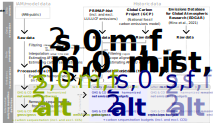

In [2]:
from IPython.core.display import SVG
SVG(url='https://raw.githubusercontent.com/AESAtoolkit/pyaesa/main/images/fig-dynamic-carrying-capacities-definition.svg')

##### Harmonization and pathway construction


For each AR6 category/SSP bucket, the function applies the same processing chain:

  **Raw filtering and yearly normalization**
   - Rows are filtered from the downloaded public explorer for one `Category` / `SSP` bucket
     and reshaped onto the package yearly grid `2000-2100`.
   - Only AR6-vetted model-scenarios are considered. 
   - Internal missing years are linearly interpolated (AR6 scenarios are provided at 5-year or 10-year
     intervals), but truncated starts and truncated ends are kept as missing values. The function
     therefore fills only *inside* existing reported spans; it does not extrapolate before the first
     reported year or after the last reported year.
   - An additional filtering ensures that `Emissions|CO2` can be reconstructed via all its subcontributions `Emissions|CO2|...` with a reconstruction error below 0.001% of cumulative emissions on the scenario time horizon.

  **AFOLU handling and variable construction**
   - The raw explorer provides direct `Emissions(net)|Kyoto Gases` and `Emissions(net)|CO2` totals, plus AFOLU
     component rows.
   - `Emissions(net)|CO2|WO AFOLU` is derived by subtracting `Emissions(net)|CO2|AFOLU` from total CO2.
   - `Emissions(net)|Kyoto Gases|AFOLU` is rebuilt from the available AFOLU gas components in the
     explorer all converted to CO2-eq GWP100 :
     `Emissions(net)|CO2|AFOLU + Emissions|CH4|AFOLU + Emissions|N2O|AFOLU`.
   - `Emissions(net)|Kyoto Gases|WO AFOLU` is then derived by subtracting that reconstructed AFOLU
     subtotal from total Kyoto Gases.
   - If the required AFOLU component rows are incomplete for certain AR6 scenarios, the package
     keeps the directly reported total (`Emissions(net)|CO2` or `Emissions(net)|Kyoto Gases`) and logs the
     derived `...|WO AFOLU` row as not produced.

  **Study window eligibility**
   - After interpolation and AFOLU handling, a row is retained only if it has a finite value at both
     the study start year and the study end year.
   - This is how the function enforces temporal comparability: pathways that start after the
     requested start year or stop before the requested end year are excluded.

  **Historical baseline and harmonization**
   - When `harmonization=True`, the function aligns AR6 pathways to observed historical emissions
     between pathways starting years and requested study start year while preserving each scenario
     cumulative emissions budget, following Gidden et al. (2018). Note that emissions infilling is 
     not performed here.
   - Historical emissions are collected by `download_ar6` from PRIMAP and Global Carbon Budget for
     bunker CO2 additions (see output folder for reference citations .txt).

   - `harmonization_method` currently supports only `"offset"`. Under this method, the pathway is
     anchored to the historical baseline at the harmonization year, the cumulative difference
     between pathway and historical emissions over the harmonization window is computed, and that
     delta is redistributed as one uniform annual correction from the year after harmonization to a
     row specific horizon so the scenario cumulative budget is preserved.
      - `constant_offset` is used when the pathway never becomes negative. The uniform annual
        correction is applied from after the study start year through the last available pathway
        year.
      - `reduced_offset` is used when the pathway reaches negative emissions. The uniform annual
        correction is applied only up to the model net zero proxy year, defined as the year
        immediately before the first negative emissions year, rather than through the full remaining
        pathway horizon.
   - Following pyaesa (de Bantel et al., 2026), pyaesa can further shorten the effective
     harmonization horizon when needed so the correction does not create an earlier negative
     emissions year than in the original pathway.

  **Estimation of gross and gross_alt emissions**
   - Harmonized net emissions are then used to estimate `gross` and `gross_alt` emissions for GHG and CO2 variables. This ensures
     that the dynamic carrying capacities is always positive, which is necessary to apply justice distributive theory with currently
     available sharing principles.
   - Based the AR6 data, carbon sequestrations are extracted for each model-scenarios and two variables are defined:
      - `Carbon Sequestration|Subtotal_seq`, as the sum of all carbon sequestrations *except* carbon capture and storage (CCS).
        This is motivated by the fact that CCS is a different form of sequestration as it acts at the *source* of emissions, whereas
        other carbon sequestration variables in the AR6 remove carbon from the atmosphere.
      - `Carbon Sequestration|Total`, as the sum of all carbon sequestration contributions, including CCS.
   - Gross emissions are then computed by removing carbon sequestration from net emissions. This yields respectively `gross_alt` 
     and `gross` variables. A final check filters out model-scenarios for which `gross_alt` and `gross` emissions are not always
     positive.

  **Final tables written**
   - `ORIGINAL_AR6` keeps the post interpolation, post AFOLU source table before harmonization.
   - The final pathways sheet keeps either harmonized retained pathways or non harmonized retained
     pathways.
   - The budget statistics sheet summarizes retained rows by AR6 category and by category/SSP
     bucket.
   - Harmonized runs also write a separate harmonization log workbook with row level correction
     diagnostics.

**References**

- Gidden, M. J., Fujimori, S., van den Berg, M., Klein, D., Smith, S. J., van Vuuren, D. P., &
  Riahi, K. (2018). A methodology and implementation of automated emissions harmonization for use in
  Integrated Assessment Models. *Environmental Modelling & Software*, 105, 187-200.
- de Bantel et al. (2026).


##### Optional diagnostic figures


When `figures=True`, figures are generated **only for harmonized runs** because the figure workflow
depends on the harmonized pathways, the historical baseline, and the harmonization log. The figure
set is diagnostic only, not necessary for any subsequent workflow. It includes:

- a **historical baseline figure** showing the PRIMAP + GCP series used for harmonization
- **pathway comparison figures** showing retained original pathways versus retained harmonized
  pathways by output variable
- **harmonization diagnostics** showing yearly correction sizes, pathway versus historical
  cumulative ratios, and timing diagnostics around the harmonization horizon / net zero behavior
- **budget figures** showing pathway panels plus study period and remaining budget distributions by
  category and by category/SSP bucket
- a **warming figure** showing the distribution of the AR6 field `Median warming in 2100
  (MAGICCv7.5.3)` for the retained model scenario pairs
- a **sequestration figure** showing the carbon sequestrations subcontributions for all model-scenarios
  included, sorted by categories.
- **figure only Monte Carlo sampling comparison figures** comparing two pathway rendering methods used
  in later uncertainty workflows: seeded simple random sampling (SRS), where each run samples
  retained pathways with equal probability, and package labelled Latin hypercube sampling (LHS),
  where runs are stratified (first IAM model is rendered then within Scenario)
    - The SRS versus LHS figure is only a diagnostic figure. The purpose is to show the effect of
      choosing one pathway rendering method or the other before selecting the Monte Carlo approach for
      the study endpoint of interest (dynamic climate change AR6 carrying capacity, aCC, or ASR)

#### When this processing option is needed


Use this processing option only if the study needs dynamic climate change carrying capacities.

`process_ar6(...)` writes the broad retained pathway table for the selected study years. Later
dynamic AR6 CC functions can then narrow the saved table by category, SSP family, or model scenario
subset, depending on the study objective.


#### Public argument checklist
The table lists all arguments; the same definitions are available in the function docstring.

<div class="pyaesa-argument-legend">
<div class="pyaesa-default-block" style="color:#087f5b"><strong>Green items = default if omitted.</strong></div>
</div>

Do not write green items when the default is intended.

<details open>
<summary><code>process_ar6(...)</code> arguments</summary>

<table>
<thead><tr><th>Argument</th><th>Description</th></tr></thead>
<tbody>
<tr><td style="vertical-align:top; white-space:nowrap;"><code>years</code></td><td>Study year selector provided as a consecutive year<br>&#10;list or <code>range(start_year, end_year + 1)</code>. The resolved years<br>&#10;must contain at least two consecutive years with no gaps.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>figures</code></td><td>Whether to render figures.<br>&#10;<strong>Default is</strong> <code>True</code>.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>harmonization</code></td><td>Whether to harmonize retained AR6 pathways to the<br>&#10;historical baseline. <strong>Defaults to</strong> <code>True</code>. If <code>True</code>, write<br>&#10;<code>harmonized_ar6_public.xlsx</code> plus<br>&#10;the separate harmonization log workbook<br>&#10;<code>harmonized_ar6_public_log.xlsx</code>. If <code>False</code>, apply the same<br>&#10;required CO2 coverage and derived variable construction filters,<br>&#10;write <code>filtered_original_ar6_public.xlsx</code>, and <strong>omit</strong> the<br>&#10;harmonization log workbook. When required component inputs are<br>&#10;missing for a derived retained variable, the package omits that<br>&#10;derived row and records the omission in the AR6 row issue log. The<br>&#10;required CO2 coverage, CO2 reconstruction, sequestration, and gross<br>&#10;emissions filters are shared with the harmonized mode. Figure<br>&#10;generation is available for harmonized runs.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>harmonization_method</code></td><td>Harmonization method applied only when<br>&#10;<code>harmonization=True</code>. <strong>Defaults to</strong> <code>&quot;offset&quot;</code>. The only<br>&#10;supported value is currently <code>&quot;offset&quot;</code>.<br>&#10;Ignored when <code>harmonization=False</code>.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>refresh</code></td><td>If <code>True</code>, clear and recompute only the resolved processed AR6 output scope for the requested study period, harmonization flag, and harmonization method. Raw downloads and downstream AR6 CC, aCC, or ASR outputs are not refreshed. <strong>Defaults to</strong> <code>False</code>.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>figure_format</code></td><td>Figure render settings mapping. <strong>Defaults to</strong><br>&#10;<code>{&quot;format&quot;: &quot;png&quot;, &quot;dpi&quot;: 500}</code>.<br>&#10;&#160;<br>&#10;Nested keys:<br>&#10;&#160;<br>&#10;&bull; <code>format</code>: Figure file format. Accepted values are <code>&quot;png&quot;</code>,<br>&#10;  <code>&quot;pdf&quot;</code>, and <code>&quot;svg&quot;</code>.<br>&#10;&bull; <code>dpi</code>: Positive integer figure resolution used for raster<br>&#10;  outputs.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>figure_convergence_tol</code></td><td>Relative convergence tolerance used only by the<br>&#10;SRS/LHS figure sampling diagnostics when <code>figures=True</code>. The <strong>default<br>&#10;is</strong> <code>5e-2</code>, i.e. a <code>5%</code> maximum relative change between successive<br>&#10;checkpoint summaries for each monitored summary statistic. Figure<br>&#10;sampling is accepted only after <code>3</code> consecutive stable checkpoint<br>&#10;comparisons. Because the figure workflow evaluates those<br>&#10;comparisons every <code>10000</code> runs per bucket, the earliest accepted<br>&#10;convergence checkpoint is <code>40000</code> completed runs per bucket.</td></tr>
<tr class="pyaesa-default-row" style="color:#087f5b;"><td style="vertical-align:top; white-space:nowrap;"><code>figure_convergence_max_runs</code></td><td>Maximum per bucket run count allowed for the<br>&#10;SRS/LHS figure sampling convergence loop when <code>figures=True</code> before<br>&#10;figure generation fails. <strong>Default</strong>: <code>20000000</code>.</td></tr>
</tbody>
</table>

</details>


### Running `process_ar6(...)`


#### Example 1: default harmonization method (`offset`)

Currently the only supported method is `offset`, so the argument can be omitted to use it by default.


In [ ]:
process_ar6(
    years=range(2019, 2061),
)

# What to do next


You have now been through the three prerequisites notebooks, congratulations!

It is now time to dive into the next batch of tutorials to discover **study objectives** and **functional units** in <span style="color:#366e9c"><strong><tt>py</tt></strong></span><span style="color:#c83737"><strong><tt>aesa</tt></strong></span>: these are two central concepts.

Start with `tutorials/study_objectives/0_study_objectives.md`.